# The Barcelona Grand Prix - 2026 🇪🇸 | The Qualifying

- This notebook is full pre-race technical debrief of the Qualifying Session at the Barcelona Grandprix, 2026.
- I have tried to work with the data the best I can considering the limitations that I have faced, most significantly not having access to the telemetry of the cars.
- Hence, I have researched technical regulations for hard limits while making resonable assumptions where possible to navigate the problems.

## Necessary Imports

In [1]:
# FastF1 Deps
import fastf1
from fastf1.core import Laps
from fastf1.plotting import get_driver_color_mapping

# Data Deps
import pandas as pd

# Visualisation Deps
import matplotlib.pyplot as plt

# Core Deps
from pathlib import Path
import sys
sys.path.append(str(Path("../../")))

# Source Deps
from src.v1.data import DataUtils
from src.v1.pipeline import DataPipeline
from src.v1.visualisation import DataVisualisation

## Notebook-Level Setup and Configurations

In [2]:
# Accessing the Current Working Directory for Absolute Root Path
REPO_ROOT_PATH = Path.cwd().parent.parent.parent

# Pathlib Path Objects for the Notebook
F1_PATH = REPO_ROOT_PATH / "F1"
CACHE_PATH = F1_PATH / "cache"
CACHE_PATH.mkdir(exist_ok=True)

# Path to store the final quali frame
f1_data_path = F1_PATH / "data"
f1_data_path.mkdir(exist_ok=True)

# Adding the source scripts into the Python Execution Path
if F1_PATH not in sys.path:
    sys.path.append(str(F1_PATH))

## Loading the Event

In [3]:
# Defaulting the Requests for Caching to a Predefined path
# fastf1.Cache.clear_cache(cache_dir=str(CACHE_PATH))
fastf1.Cache.enable_cache(cache_dir=str(CACHE_PATH))

# Enabling Offline Mode
fastf1.Cache.offline_mode(enabled=True)

# The GP Event
barcelona_2026 = fastf1.get_event(
    year=2026,
    gp="barcelona"
)
print(barcelona_2026)

RoundNumber                                                          7
Country                                                          Spain
Location                                                     Barcelona
OfficialEventName    FORMULA 1 MSC CRUISES GRAN PREMIO DE BARCELONA...
EventDate                                          2026-06-14 00:00:00
EventName                                         Barcelona Grand Prix
EventFormat                                               conventional
Session1                                                    Practice 1
Session1Date                                 2026-06-12 13:30:00+02:00
Session1DateUtc                                    2026-06-12 11:30:00
Session2                                                    Practice 2
Session2Date                                 2026-06-12 17:00:00+02:00
Session2DateUtc                                    2026-06-12 15:00:00
Session3                                                    Practice 3
Sessio

In [4]:
barcelona_2026 = DataUtils(race_event=barcelona_2026)
quali, race = barcelona_2026.load_data()

core           INFO 	Loading data for Barcelona Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '44', '12', '1', '3', '6', '81', '30', '27', '16', '41', '5', '43', '10', '87', '55', '31', '23', '11', '77', '18', '14']
core           INFO 	Loading data for Barcelona Grand Prix - Race [v3.8.3]
req            INFO 

## Data Engineering

<img src="../../../assets/circuit_maps/barcelona_map.avif">

In [5]:
# Instantiating the DataPipeline
data_pipe = DataPipeline()

In [6]:
# Full Laps Frame
assert quali, "Qualifying was not loaded"
quali_laps_full = quali.laps

# Drop columns
drop_cols = [
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", 
    "DeletedReason", "FastF1Generated", "IsAccurate", "Time"
]

# Filtered Laps
_, _, q3 = quali_laps_full.split_qualifying_sessions()
assert isinstance(q3, Laps), "Q3 Laps was None"
filtered_quali_laps = q3.drop(drop_cols, axis=1)

# Rounding down to the laps of the top runners
assert race, "Race was not loaded"
top_4_drivers = race.results.iloc[:4]["DriverNumber"].to_list()

# Retrieving the best laps
fastest_quali_laps = data_pipe.get_filtered_quali_laps(
    laps_frame=filtered_quali_laps,
    drivers=top_4_drivers
)

fastest_quali_laps.head()

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,HAM,0 days 00:00:21.873000,0 days 00:00:30.008000,0 days 00:00:22.849000,0 days 00:01:14.743000,268.0,294.0,295.0,333.0
1,NOR,0 days 00:00:21.928000,0 days 00:00:30.237000,0 days 00:00:22.772000,0 days 00:01:15.001000,274.0,292.0,292.0,333.0
2,RUS,0 days 00:00:21.849000,0 days 00:00:30.115000,0 days 00:00:22.715000,0 days 00:01:14.679000,274.0,281.0,298.0,332.0
3,VER,0 days 00:00:21.828000,0 days 00:00:30.184000,0 days 00:00:22.875000,0 days 00:01:15.021000,280.0,291.0,294.0,333.0


In [7]:
# Transforming all the timedelta objects
get_seconds = pd.Timedelta.total_seconds

fastest_quali_laps["LapTime"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["LapTime"]),
    axis=1
)
fastest_quali_laps["Sector1Time"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["Sector1Time"]),
    axis=1
)
fastest_quali_laps["Sector2Time"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["Sector2Time"]),
    axis=1
)
fastest_quali_laps["Sector3Time"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["Sector3Time"]),
    axis=1
)

fastest_quali_laps.head()

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,HAM,21.873,30.008,22.849,74.743,268.0,294.0,295.0,333.0
1,NOR,21.928,30.237,22.772,75.001,274.0,292.0,292.0,333.0
2,RUS,21.849,30.115,22.715,74.679,274.0,281.0,298.0,332.0
3,VER,21.828,30.184,22.875,75.021,280.0,291.0,294.0,333.0


In [8]:
def display_sector_stat(driver_lap: pd.Series, sector: int) -> None:
    """Helper function to display the driver stats."""
    
    print(f"Sector - {sector}")
    print(f"Driver: {driver_lap['Driver']}")

    if sector == 1:
        print(f"Sector Time: {driver_lap['Sector1Time']}")
        print(f"Speed I1: {driver_lap['SpeedI1']}")
    elif sector == 2:
        print(f"Sector Time: {driver_lap['Sector2Time']}")
        print(f"Speed I2: {driver_lap['SpeedI2']}")
    else:
        print(f"Sector Time: {driver_lap['Sector3Time']}")
        print(f"Speed I3: {driver_lap['SpeedFL']}")

    print(f"Longest Straight Speed: {driver_lap['SpeedST']}\n")

In [9]:
# Sector Enum
sectors = ["Sector1Time", "Sector2Time", "Sector3Time"]

# The Theoritical Best Time
best_times = {}

print("Theoritical Best Sectors:\n")
for idx, key in enumerate(sectors):
    fastest_sector = fastest_quali_laps.loc[fastest_quali_laps[key].idxmin()]
    best_times[key] = fastest_sector[key]
    
    assert isinstance(fastest_sector, pd.Series), f"Fastest sector was not found for {key}"
    display_sector_stat(fastest_sector, sector=idx+1)

fastest_laptime = (
    best_times["Sector1Time"] 
    + best_times["Sector2Time"] 
    + best_times["Sector3Time"]
)
print(f"Theoretical Best Time: {fastest_laptime}")

Theoritical Best Sectors:

Sector - 1
Driver: VER
Sector Time: 21.828
Speed I1: 280.0
Longest Straight Speed: 333.0

Sector - 2
Driver: HAM
Sector Time: 30.008
Speed I2: 294.0
Longest Straight Speed: 333.0

Sector - 3
Driver: RUS
Sector Time: 22.715
Speed I3: 298.0
Longest Straight Speed: 332.0

Theoretical Best Time: 74.551


## Important Point Stats

### Aero Efficiency Index
Comparing the average speed maintained in High-Downforce Sections to the Low-Drag Sections to assess the tradeoff applied by teams in the setup of the car. However, this tradeoff has a little hidden complexity in that a track like Barcelona test two things:
1. `Front-Axle Aero`: Sector - 1; High Straight Line Speed and Cornerning with long radius. This tests the front axle bite on corner entry allowing the driver gain or loose more speed.
2. `Balanced Aero`: Sector - 2: The Short to Medium long straights alongside the tight and twisty initial corners test for a balanced Chassis that can utilise both the Straight Mode zones while having enough aero to corner well.
3. `Rear-Axle Downforce`: Sector - 3; Medium to Low Speed Corners with little to no Straights. This tests the rear axle traction of the car to provide a smooth, predictable feedback through the section. This is highly dependent on the downforce generated by the car.

In [10]:
fastest_quali_laps.loc[:, "FrontAEI"] = fastest_quali_laps.apply(
    lambda x: data_pipe.get_aero_efficiency(
        v_sector=x["SpeedI1"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector1Time"]
    ),
    axis=1
)

fastest_quali_laps.loc[:, "BalancedAEI"] = fastest_quali_laps.apply(
    lambda x: data_pipe.get_aero_efficiency(
        v_sector=x["SpeedI2"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector2Time"]
    ),
    axis=1
)

fastest_quali_laps.loc[:, "RearAEI"] = fastest_quali_laps.apply(
    lambda x: data_pipe.get_aero_efficiency(
        v_sector=x["SpeedFL"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector3Time"]
    ),
    axis=1
)

fastest_quali_laps

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI
0,HAM,21.873,30.008,22.849,74.743,268.0,294.0,295.0,333.0,17.603495,26.493550,20.241607
1,NOR,21.928,30.237,22.772,75.001,274.0,292.0,292.0,333.0,18.042859,26.514126,19.968240
2,RUS,21.849,30.115,22.715,74.679,274.0,281.0,298.0,332.0,18.032006,25.488901,20.388765
3,VER,21.828,30.184,22.875,75.021,280.0,291.0,294.0,333.0,18.353874,26.377009,20.195946


### Power Unit Performance Index
- The Power Unit Performance is estimated by direct calculations of the Change in Kinetic Energy of the Drivers and Chassis through different sectors of the circuit wrt the Peak Kinetic Energy as deployed on the Main Straight indicated by SpeedST.
- Subsequently, a calculation the Power expenditure Rate of Change of Kinetic Energy is used to anchor the energy usage for the current era of Hybrids through each of the sectors.

In [11]:
# Adding the Acceleration Time
fastest_quali_laps.loc[:, "AccelerationTime"] = fastest_quali_laps.apply(
    lambda x: data_pipe.get_delta_acceleration_time(
        circuit="barcelona", 
        v1=x["SpeedFL"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# Adding the Kinetic Energies
fastest_quali_laps.loc[:, "KineticEnergyS1"] = fastest_quali_laps.apply(
    lambda x: data_pipe.get_delta_kinetic_energy(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)
fastest_quali_laps.loc[:, "KineticEnergyS2"] = fastest_quali_laps.apply(
    lambda x: data_pipe.get_delta_kinetic_energy(
        v1=x["SpeedI2"], 
        v2=x["SpeedST"]
    ),
    axis=1
)
fastest_quali_laps.loc[:, "KineticEnergyS3"] = fastest_quali_laps.apply(
    lambda x: data_pipe.get_delta_kinetic_energy(
        v1=x["SpeedFL"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# Adding the Power in KW
fastest_quali_laps["PowerS1"] = fastest_quali_laps["KineticEnergyS1"] / fastest_quali_laps["Sector1Time"]
fastest_quali_laps["PowerS2"] = fastest_quali_laps["KineticEnergyS2"] / fastest_quali_laps["Sector2Time"]
fastest_quali_laps["PowerS3"] = fastest_quali_laps["KineticEnergyS3"] / fastest_quali_laps["Sector3Time"]

fastest_quali_laps["ERS_Clipping"] = fastest_quali_laps["SpeedST"] / fastest_quali_laps["SpeedFL"]
fastest_quali_laps

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,FrontAEI,BalancedAEI,RearAEI,AccelerationTime,KineticEnergyS1,KineticEnergyS2,KineticEnergyS3,PowerS1,PowerS2,PowerS3,ERS_Clipping
0,HAM,21.873,30.008,22.849,74.743,268.0,294.0,295.0,333.0,17.603495,26.493550,20.241607,5.044586,116.351003,72.830694,71.076420,5.319389,2.427043,3.110702,1.128814
1,NOR,21.928,30.237,22.772,75.001,274.0,292.0,292.0,333.0,18.042859,26.514126,19.968240,5.068800,106.665262,76.321373,76.321373,4.864341,2.524105,3.351545,1.140411
2,RUS,21.849,30.115,22.715,74.679,274.0,281.0,298.0,332.0,18.032006,25.488901,20.388765,5.028571,104.684630,93.113565,63.797222,4.791278,3.091933,2.808594,1.114094
3,VER,21.828,30.184,22.875,75.021,280.0,291.0,294.0,333.0,18.353874,26.377009,20.195946,5.052632,96.765077,78.057778,72.830694,4.433071,2.586065,3.183855,1.132653


## Data Visualisation

In [12]:
top_4_drivers = fastest_quali_laps["Driver"].unique().tolist()
top_4_drivers

['HAM', 'NOR', 'RUS', 'VER']

In [13]:
assert quali, "Quali Session wasn't Loaded"

# Color Maps to Use
colors = get_driver_color_mapping(session=quali)
driver_colors = {}

for driver in top_4_drivers:
    driver_colors[driver] = colors[driver]

driver_colors

req            INFO 	Using cached data for driver_info


{'HAM': '#e80020', 'NOR': '#ff8000', 'RUS': '#27f4d2', 'VER': '#0600ef'}

In [14]:
# Instantiating the Data Visualisation Handle
assert quali, "The Quali Session wasn't loaded"
data_vis = DataVisualisation(session=quali, driver_names=top_4_drivers)

### Aero Efficiency Plot
- Top Left Corner is better for each individual sector based on the characteristics of the sector.
- Higher AEI (although brokendown into three plots) is indicative of the aerodynamic performance of the chassis to keep a higher minimum speed through each of the individual sectors in comparison to their top speed.

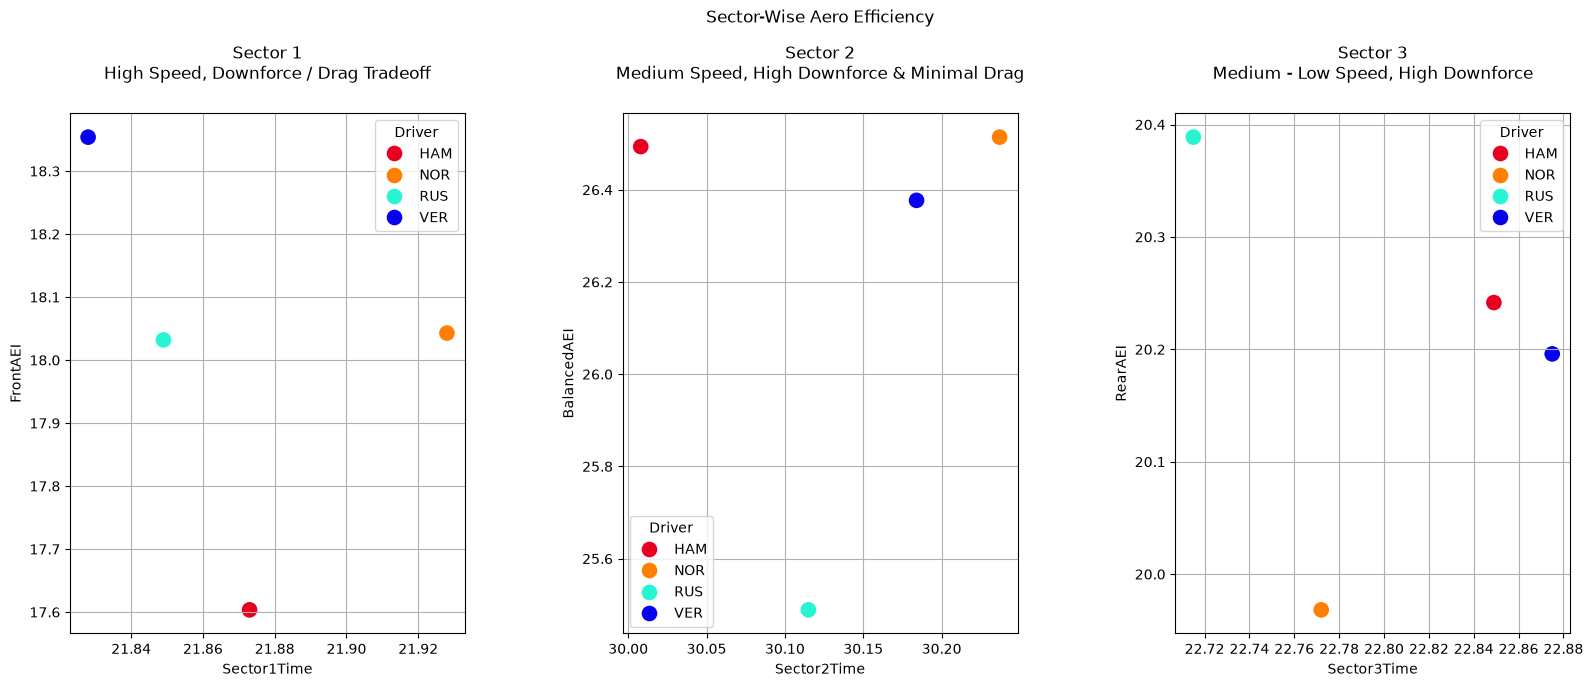

In [15]:
aei_fig = data_vis.create_scatter_plots(
    nrows=1,
    ncols=3,
    figsize=(25, 8),
    data=fastest_quali_laps,
    hue="Driver",
    size=150,
    plot_kind="aero"
)

aei_fig.suptitle("Sector-Wise Aero Efficiency")
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.4)
plt.show()

### Kinetic Energy Retention Plot
- Lower is better for each individual sector based on the characteristics of the sector.
- Lower indicates better exit through the corners and the straights throughout the specific sector thereby matching a driver's respective top speed.

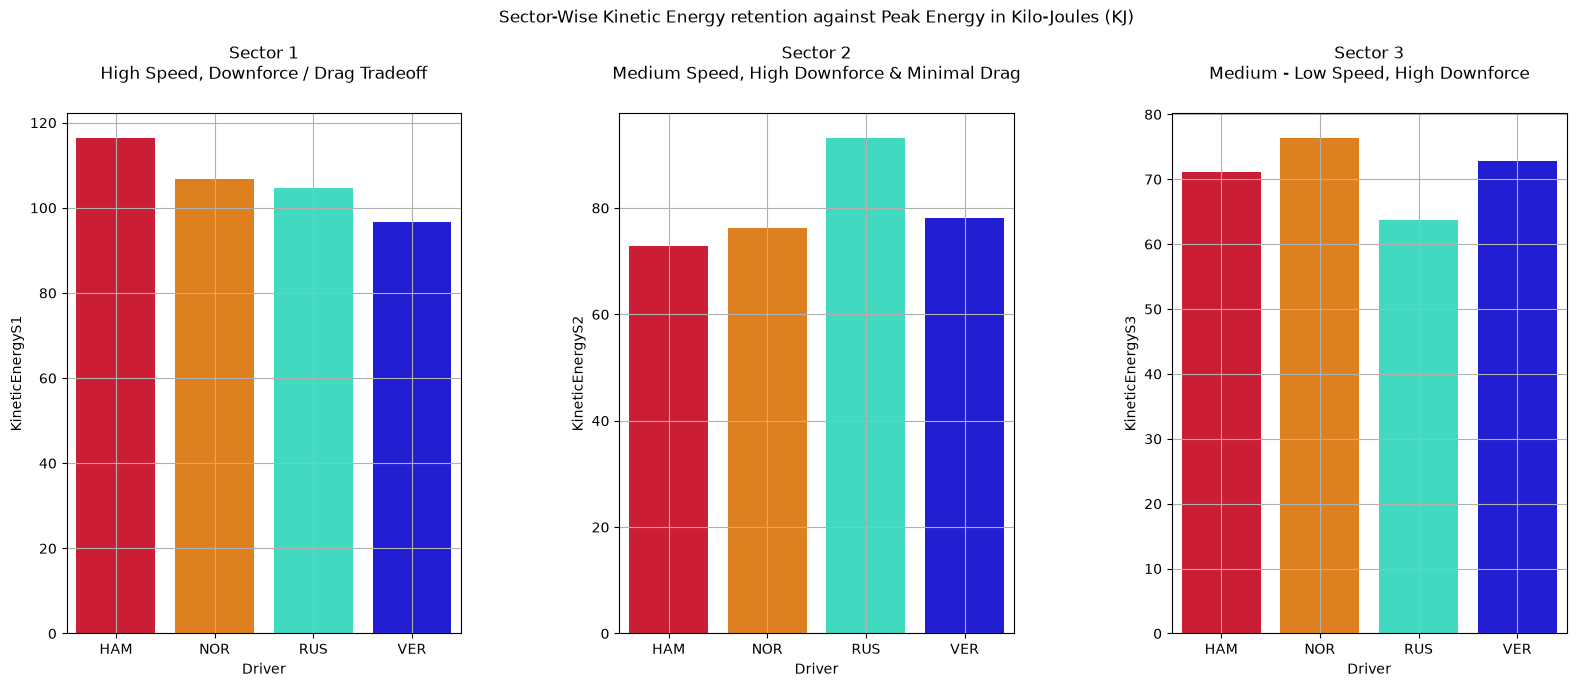

In [16]:
kep_fig = data_vis.create_bar_plots(
    nrows=1, 
    ncols=3,
    figsize=(25, 8),
    data=fastest_quali_laps,
    hue="Driver",
    plot_kind="ke"
)

kep_fig.suptitle("Sector-Wise Kinetic Energy retention against Peak Energy in Kilo-Joules (KJ)")
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.4)
plt.show()

### Energy Deployment Plot
- Ideally, Lower is better. However, atleast for 2026 this won't be the case as the teams scour to source more data from the cars through a calendar season.
- Additionally, the trends of deployments wrt each sector provide insight into the strategies that were utilised be each teams based on their respective setups to generate the fast lap.
- This to me personally was fascinating to see, although I don't have telemetry for this notebook looking through the traces on GP Tempo the below graphs checkout for respective characteristics of each fo the cars as follows:
    * `Ferrari - Hamilton`: Are slower on the straights while faster in the corners (however, not by much*) thus; a large part of their deployment is on the long main straight.
    * `Mercedes - Russell, Norris`: While the PU is the same and thereby their respective performance for Sector - 1 is similar, Norris appears to have run of energy towards the end. While Russell deploys heavily in Sector - 2 to reduce the delta to the Ferrari and capitalises in Sector - 3 (Traction Sector).
    * `RedBull - Verstappen`: Are the best in Sector - 1 (Ig, that's why they didn't meet the ADUO afterall, 😭) and really close to Ferrari in Sector - 2. However, they seem to loose all their hardwork in Sector - 3 with less grip, provisionally skinny rear wing as verified earlier by the AEI.

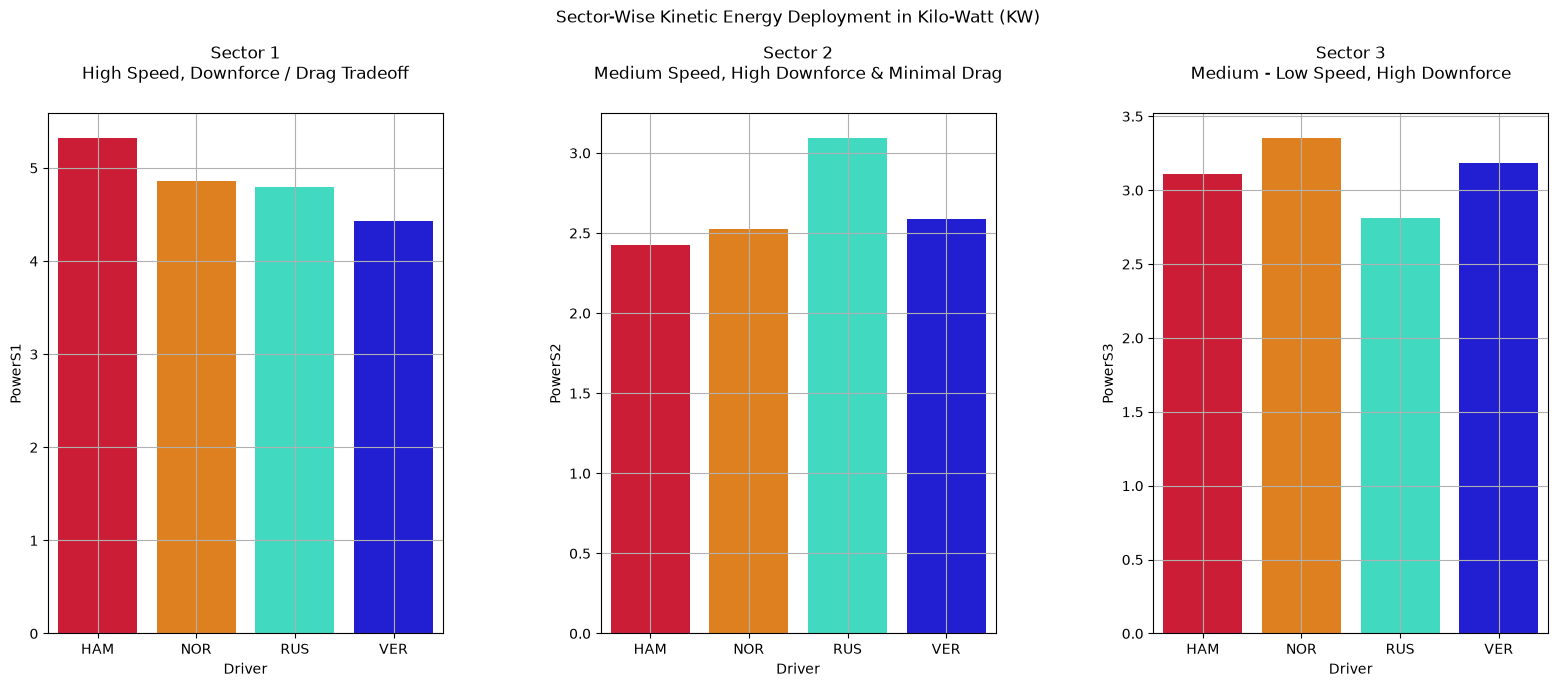

In [17]:
power_fig = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(25, 8),
    data=fastest_quali_laps,
    hue="Driver",
    plot_kind="power"
)

power_fig.suptitle("Sector-Wise Kinetic Energy Deployment in Kilo-Watt (KW)")
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.85, wspace=0.4)
plt.show()

### ICE Strength Plot ⚠️
- Now, read this graph with a pinch of salt as it can indicate two things:
    1. The metric is heavily dependent on the speed at the Finish Line, thus the exit from the final corner in the prep-lap is extremely important. Thus if speed at the Finish Line is low, the PU has to do more work thereby reaching clipping early.
    2. If the driver does get a good exit, there is lesser acceleration time as the car reaches terminal velocity before D-Rating the MGUK thus any further acceleration is purely indicative of the strength of the ICE.

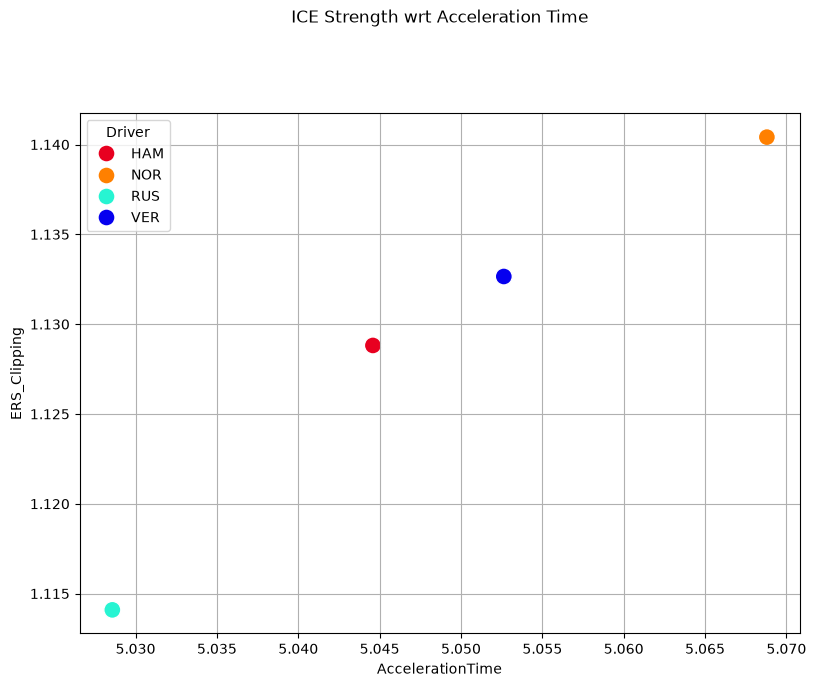

In [18]:
ice_fig = data_vis.create_scatter_plots(
    nrows=1,
    ncols=1,
    figsize=(12, 8),
    data=fastest_quali_laps,
    hue="Driver",
    size=150,
    plot_kind="ers_clip"
)

ice_fig.suptitle("ICE Strength wrt Acceleration Time")
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.85)
plt.show()

In [19]:
# Saving the final frame
fastest_quali_laps.to_csv(f1_data_path / "quali_performance.csv", index=False)

## Cheers 🙃!
Now time to put data into work in the race debrief.